In [1]:
import pandas as pd
import numpy as np

In [2]:
DATA_PATH = "../data/raw/UCI_Credit_Card.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [4]:
df.dtypes

ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
dtype: object

In [5]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [7]:
target = "default.payment.next.month"

print(df[target].value_counts())

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


In [8]:
target_distribution = df[target].value_counts(normalize=True) * 100

print(target_distribution)

default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


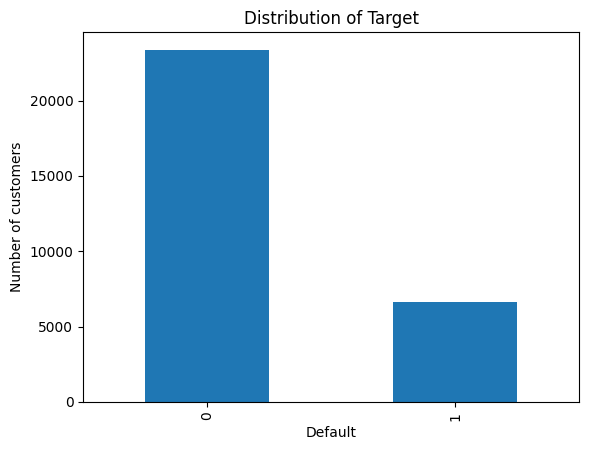

In [9]:
import matplotlib.pyplot as plt

df[target].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Default")
plt.ylabel("Number of customers")
plt.title("Distribution of Target")
plt.show()

In [10]:
print(df["EDUCATION"].value_counts().sort_index())

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64


In [11]:
print(df["MARRIAGE"].value_counts().sort_index())

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [12]:
pay_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

for col in pay_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().sort_index())


--- PAY_0 ---
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

--- PAY_2 ---
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

--- PAY_3 ---
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

--- PAY_4 ---
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

--- PAY_5 ---
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

--- PAY_6 ---
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19


In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns

print(numeric_cols.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


In [14]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "feature": col,
        "outliers": count,
        "percentage": count / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    "outliers",
    ascending=False
)

,feature,outliers,percentage
24,default.payment.next.month,6636,22.120000
7,PAY_2,4410,14.700000
8,PAY_3,4209,14.030000
9,PAY_4,3508,11.693333
6,PAY_0,3130,10.433333
11,PAY_6,3079,10.263333
21,PAY_AMT4,2994,9.980000
10,PAY_5,2968,9.893333
23,PAY_AMT6,2958,9.860000
22,PAY_AMT5,2945,9.816667


In [15]:
df = df.rename(columns={"PAY_0": "PAY_1"})

In [16]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


In [17]:
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("PAY_0 exists:", "PAY_0" in df.columns)
print("PAY_1 exists:", "PAY_1" in df.columns)

Dataset shape: (30000, 25)
Missing values: 0
PAY_0 exists: False
PAY_1 exists: True


### Handling undocumented codes

The dataset contains several undocumented or special codes:

- EDUCATION: 0, 5, 6
- MARRIAGE: 0
- PAY_x: -2, 0

These values will be reviewed during preprocessing rather than removed directly.

In [18]:
special_codes = {
    "EDUCATION": [0, 5, 6],
    "MARRIAGE": [0],
    "PAY_1": [-2, 0],
    "PAY_2": [-2, 0],
    "PAY_3": [-2, 0],
    "PAY_4": [-2, 0],
    "PAY_5": [-2, 0],
    "PAY_6": [-2, 0],
}

for col, codes in special_codes.items():
    print(f"\n{col}")
    for code in codes:
        count = (df[col] == code).sum()
        print(f"  {code}: {count} ({count / len(df) * 100:.2f}%)")


EDUCATION
  0: 14 (0.05%)
  5: 280 (0.93%)
  6: 51 (0.17%)

MARRIAGE
  0: 54 (0.18%)

PAY_1
  -2: 2759 (9.20%)
  0: 14737 (49.12%)

PAY_2
  -2: 3782 (12.61%)
  0: 15730 (52.43%)

PAY_3
  -2: 4085 (13.62%)
  0: 15764 (52.55%)

PAY_4
  -2: 4348 (14.49%)
  0: 16455 (54.85%)

PAY_5
  -2: 4546 (15.15%)
  0: 16947 (56.49%)

PAY_6
  -2: 4895 (16.32%)
  0: 16286 (54.29%)


### Preliminary preprocessing decisions

- EDUCATION codes 0, 5, 6 will be treated as undocumented education categories and grouped into a common category during preprocessing.
- MARRIAGE code 0 will be treated as an undocumented category.
- PAY_1 to PAY_6 codes -2 and 0 will be retained initially and handled as special repayment-status categories rather than being removed.
- PAY_0 is renamed to PAY_1 for consistency with the six monthly repayment-status variables.